# CineStat - Part 1: Exploring the Movie Dataset

**Course:** DS 1116 - Object Oriented Programming for Data Science Laboratory
**Dataset:** 7,668 films released between 1980 and 2020, scraped from IMDb

This notebook answers questions about the film industry: which genres make money,
whether big budgets buy good reviews, and whether we can predict what a film will earn
before it is made.

All the classes used below live in the `cinestat/` package. The Tkinter app in Part 2
imports **exactly the same classes** - the analysis is written once and used twice.

## 0. Setup

In [1]:
import sys
from pathlib import Path

# The notebook lives in notebooks/, but the cinestat package lives one level up,
# so we add the project folder to the list of places Python looks for imports.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cinestat import CSVLoader, SuccessPredictor
from cinestat import GenreAnalyzer, TrendAnalyzer, FinancialAnalyzer
from cinestat.utils import money

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Setup complete.")

Setup complete.


## 1. Load and inspect the raw data

`CSVLoader` is a subclass of the abstract class `DataLoader`. Creating it checks that
the file exists, and `.load()` is the method it overrides to actually read the CSV.

In [2]:
loader = CSVLoader(PROJECT_ROOT / "data" / "movies.csv")
raw = loader.load()

print(f"The raw file has {raw.shape[0]:,} rows and {raw.shape[1]} columns.")
raw.head()

The raw file has 7,668 rows and 15 columns.


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.40,"927,000.00",Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,"19,000,000.00","46,998,772.00",Warner Bros.,146.00
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.80,"65,000.00",Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,"4,500,000.00","58,853,106.00",Columbia Pictures,104.00
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.70,"1,200,000.00",Irvin Kershner,Leigh Brackett,Mark Hamill,United States,"18,000,000.00","538,375,067.00",Lucasfilm,124.00
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.70,"221,000.00",Jim Abrahams,Jim Abrahams,Robert Hays,United States,"3,500,000.00","83,453,539.00",Paramount Pictures,88.00
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.30,"108,000.00",Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,"6,000,000.00","39,846,344.00",Orion Pictures,98.00


In [3]:
# What type is each column, and how much data is missing?
print(raw.dtypes, end="\n\n")
print("Missing values per column:")
print(raw.isna().sum().sort_values(ascending=False))

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

Missing values per column:
budget      2171
gross        189
rating        77
company       17
runtime        4
score          3
votes          3
writer         3
country        3
released       2
star           1
name           0
genre          0
year           0
director       0
dtype: int64


**Takeaway:** the file is mostly complete, but **2,171 films have no budget** recorded
and 189 have no box-office figure. Those are the two columns our whole analysis depends
on, so they have to be dealt with before we go any further.

## 2. Clean the data

The `clean()` method is written once in the abstract `DataLoader` class and inherited by
every loader. It does five things:

1. Drops duplicate rows
2. Drops rows with no budget, gross, runtime, rating or genre
3. Pulls the **release month** out of the `released` text column
4. Calculates `profit` and `roi` (return on investment)
5. Groups rare genres together as `"Other"`

### A trap hiding in the `released` column

`released` is free text like `"June 13, 1980 (United States)"`, so the first word is
*usually* the month. But not always - a few rows have a **year** where the month should
be. If we trusted the first word blindly, our seasonality analysis would silently
contain nonsense months. `clean()` keeps only real month names.

In [4]:
print("Examples of the released column:")
for value in raw["released"].dropna().head(3):
    print("  ", value)

first_word = raw["released"].astype(str).str.split().str[0]
bad_values = sorted(set(first_word) - set(CSVLoader.MONTHS))
print(f"\nFirst words that are NOT month names: {bad_values}")
print(f"Number of rows affected: {first_word.isin(bad_values).sum()}")

Examples of the released column:
   June 13, 1980 (United States)
   July 2, 1980 (United States)
   June 20, 1980 (United States)

First words that are NOT month names: ['1981', '1982', '1985', '1987', '1990', '1995', '2013', '2019', 'nan']
Number of rows affected: 12


In [5]:
df = loader.clean(raw)

print(f"Before cleaning: {len(raw):,} rows")
print(f"After cleaning:  {len(df):,} rows")
print(f"Removed:         {len(raw) - len(df):,} rows "
      f"({(len(raw) - len(df)) / len(raw) * 100:.1f}%)")

df[["name", "year", "genre", "genre_group", "rating",
    "month", "budget", "gross", "profit", "roi"]].head()

Before cleaning: 7,668 rows
After cleaning:  5,418 rows
Removed:         2,250 rows (29.3%)


,name,year,genre,genre_group,rating,month,budget,gross,profit,roi
0,The Shining,1980,Drama,Drama,R,June,"19,000,000.00","46,998,772.00","27,998,772.00",2.47
1,The Blue Lagoon,1980,Adventure,Adventure,R,July,"4,500,000.00","58,853,106.00","54,353,106.00",13.08
2,Star Wars: Episode V - The Empire Strikes Back,1980,Action,Action,PG,June,"18,000,000.00","538,375,067.00","520,375,067.00",29.91
3,Airplane!,1980,Comedy,Comedy,PG,July,"3,500,000.00","83,453,539.00","79,953,539.00",23.84
4,Caddyshack,1980,Comedy,Comedy,R,July,"6,000,000.00","39,846,344.00","33,846,344.00",6.64


**Takeaway:** we keep **5,418 films** - about 71% of the original file. Losing 29% of the
rows sounds bad, but a film with no budget recorded cannot tell us anything about the
relationship between spending and earning, so keeping it would be worse than dropping it.

## 3. How are budgets and revenues distributed?

Before doing any statistics, always look at the shape of the data.

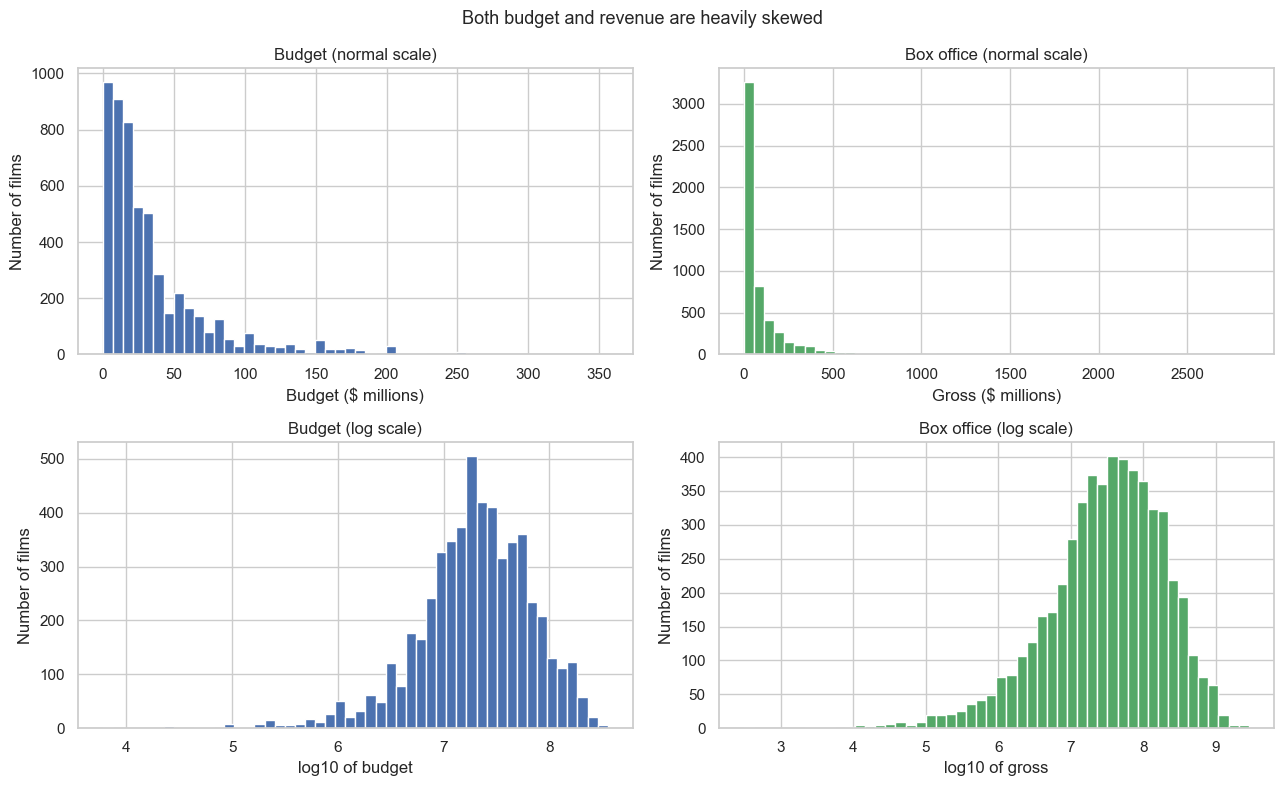

              budget            gross           profit       roi  runtime  \
count       5,418.00         5,418.00         5,418.00  5,418.00 5,418.00   
mean   36,023,908.11   103,287,186.70    67,263,278.59      6.73   108.16   
std    41,579,850.41   187,338,613.28   159,037,779.25    184.15    18.12   
min         6,000.00           309.00  -158,031,147.00      0.00    63.00   
25%    10,000,000.00    10,765,091.75    -3,173,056.50      0.72    95.00   
50%    22,000,000.00    36,965,947.00    13,882,024.50      1.84   105.00   
75%    45,000,000.00   112,556,370.50    70,408,741.75      3.67   118.00   
max   356,000,000.00 2,847,246,203.00 2,610,246,203.00 12,890.39   271.00   

         score  
count 5,418.00  
mean      6.39  
std       0.96  
min       1.90  
25%       5.80  
50%       6.50  
75%       7.10  
max       9.30  

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(df["budget"] / 1e6, bins=50, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title("Budget (normal scale)")
axes[0, 0].set_xlabel("Budget ($ millions)")

axes[0, 1].hist(df["gross"] / 1e6, bins=50, color="#55A868", edgecolor="white")
axes[0, 1].set_title("Box office (normal scale)")
axes[0, 1].set_xlabel("Gross ($ millions)")

axes[1, 0].hist(np.log10(df["budget"]), bins=50, color="#4C72B0", edgecolor="white")
axes[1, 0].set_title("Budget (log scale)")
axes[1, 0].set_xlabel("log10 of budget")

axes[1, 1].hist(np.log10(df["gross"]), bins=50, color="#55A868", edgecolor="white")
axes[1, 1].set_title("Box office (log scale)")
axes[1, 1].set_xlabel("log10 of gross")

for ax in axes.flat:
    ax.set_ylabel("Number of films")

plt.suptitle("Both budget and revenue are heavily skewed", fontsize=13)
plt.tight_layout()
plt.show()

print(df[["budget", "gross", "profit", "roi", "runtime", "score"]].describe())

**Takeaway:** the top row is squashed against the left edge - most films are cheap, and a
small handful are enormous. This is called a **right-skewed** distribution. On a log scale
(bottom row) the same data turns into a neat bell shape, which is why log scales are used
so often with money.

## 4. Leaderboards: the best and the worst

In [7]:
def leaderboard(column, title, formatter=money, n=10):
    """Print the top n films ranked by one column."""
    top = df.nlargest(n, column)
    print(f"--- {title} ---")
    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        value = formatter(row[column]) if formatter else f"{row[column]:.2f}"
        print(f"{rank:2}. {row['name'][:38]:<40} {row['year']}  {value}")
    print()

leaderboard("gross", "Highest box office")
leaderboard("profit", "Biggest profit")
leaderboard("roi", "Best return on investment", formatter=lambda v: f"{v:.0f}x")
leaderboard("score", "Highest IMDb score", formatter=lambda v: f"{v:.1f}/10")

--- Highest box office ---
 1. Avatar                                   2009  $2.85B
 2. Avengers: Endgame                        2019  $2.80B
 3. Titanic                                  1997  $2.20B
 4. Star Wars: Episode VII - The Force Awa   2015  $2.07B
 5. Avengers: Infinity War                   2018  $2.05B
 6. The Lion King                            2019  $1.67B
 7. Jurassic World                           2015  $1.67B
 8. The Avengers                             2012  $1.52B
 9. Furious 7                                2015  $1.52B
10. Frozen II                                2019  $1.45B

--- Biggest profit ---
 1. Avatar                                   2009  $2.61B
 2. Avengers: Endgame                        2019  $2.44B
 3. Titanic                                  1997  $2.00B
 4. Star Wars: Episode VII - The Force Awa   2015  $1.82B
 5. Avengers: Infinity War                   2018  $1.73B
 6. Jurassic World                           2015  $1.52B
 7. The Lion King    

In [8]:
# The other end: films that lost the most money.
worst = df.nsmallest(10, "profit")
print("--- Biggest losses ---")
for rank, (_, row) in enumerate(worst.iterrows(), start=1):
    print(f"{rank:2}. {row['name'][:38]:<40} {row['year']}  {money(row['profit'])}")

--- Biggest losses ---
 1. The Irishman                             2019  -$158.0M
 2. The 13th Warrior                         1999  -$98.3M
 3. The Adventures of Pluto Nash             2002  -$92.9M
 4. Jin ling shi san chai                    2011  -$91.1M
 5. Cutthroat Island                         1995  -$88.0M
 6. Live by Night                            2016  -$85.3M
 7. The Alamo                                2004  -$81.2M
 8. Supernova                                2000  -$75.2M
 9. Missing Link                             2019  -$73.4M
10. How Do You Know                          2010  -$71.3M


**Takeaway:** the *highest grossing* and the *best return on investment* lists share almost
no films. Blockbusters earn the most money in total, but cheap horror films earn the most
money **per dollar spent** - a completely different definition of success.

## 5. Which genre should you invest in?

Here we use the `GenreAnalyzer` class. It inherits from the abstract `BaseAnalyzer`,
and its `run()` method is wrapped in the `@timed` decorator - that is why a timing line
appears in the output.

In [9]:
genre_analysis = GenreAnalyzer(CSVLoader(PROJECT_ROOT / "data" / "movies.csv").to_collection())
genre_table = genre_analysis.report()
genre_table

[timed] run took 4.3 ms

=== Genre Analysis ===
 * Best return on investment: Horror (3.08x the budget, typically)
 * Biggest average earner: Animation ($281.1M per film)
 * Safest genre: Animation (only 15.5% of films lose money)


,movies,avg_budget,avg_gross,avg_profit,median_roi,avg_score,flop_rate
genre_group,,,,,,,
Horror,251,"13,434,529.88","56,816,952.32","43,382,422.44",3.08,5.83,19.92
Animation,277,"76,323,357.40","281,104,365.02","204,781,007.62",2.92,6.69,15.52
Other,81,"22,413,580.26","79,308,286.81","56,894,706.56",2.06,6.25,34.57
Adventure,327,"45,958,899.08","133,268,232.13","87,309,333.05",1.88,6.27,34.25
Action,1415,"58,468,560.47","168,023,228.81","109,554,668.34",1.87,6.25,27.21
Comedy,1495,"22,812,941.95","59,207,215.92","36,394,273.97",1.79,6.19,33.04
Drama,862,"23,260,545.23","60,439,139.31","37,178,594.08",1.52,6.72,39.79
Biography,311,"25,441,574.82","61,403,451.56","35,961,876.75",1.48,7.09,35.37
Crime,399,"22,602,897.44","50,169,579.35","27,566,681.91",1.30,6.69,44.11


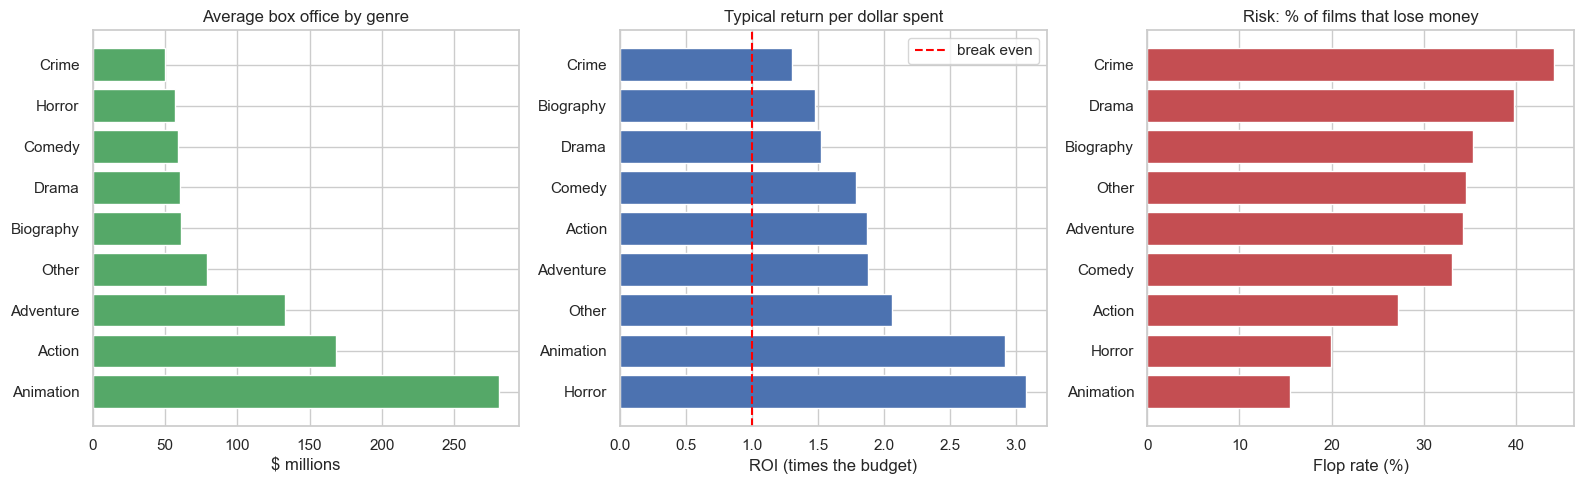

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ordered = genre_table.sort_values("avg_gross", ascending=False)
axes[0].barh(ordered.index, ordered["avg_gross"] / 1e6, color="#55A868")
axes[0].set_title("Average box office by genre")
axes[0].set_xlabel("$ millions")

ordered = genre_table.sort_values("median_roi", ascending=False)
axes[1].barh(ordered.index, ordered["median_roi"], color="#4C72B0")
axes[1].set_title("Typical return per dollar spent")
axes[1].set_xlabel("ROI (times the budget)")
axes[1].axvline(1.0, color="red", linestyle="--", label="break even")
axes[1].legend()

ordered = genre_table.sort_values("flop_rate", ascending=True)
axes[2].barh(ordered.index, ordered["flop_rate"], color="#C44E52")
axes[2].set_title("Risk: % of films that lose money")
axes[2].set_xlabel("Flop rate (%)")

plt.tight_layout()
plt.show()

**Takeaway:** these three charts disagree, and that is the interesting part.
**Animation** earns the most money per film and is the *safest* bet, but it is also the
most expensive to make. **Horror** earns the least in total yet gives the best return per
dollar - a cheap horror film typically makes back about **3x** its budget.

## 6. How has the industry changed since 1980?

`TrendAnalyzer` is a different subclass of the same `BaseAnalyzer`. Notice that we use it
in exactly the same way as `GenreAnalyzer` - that is **polymorphism**.

[timed] run took 1.7 ms

=== Trends Over Time ===
 * Average budget in 1980: $11.6M; in 2020: $107.7M
 * That is 9.3x more expensive to make a film
 * Average IMDb score moved from 6.51 to 6.61


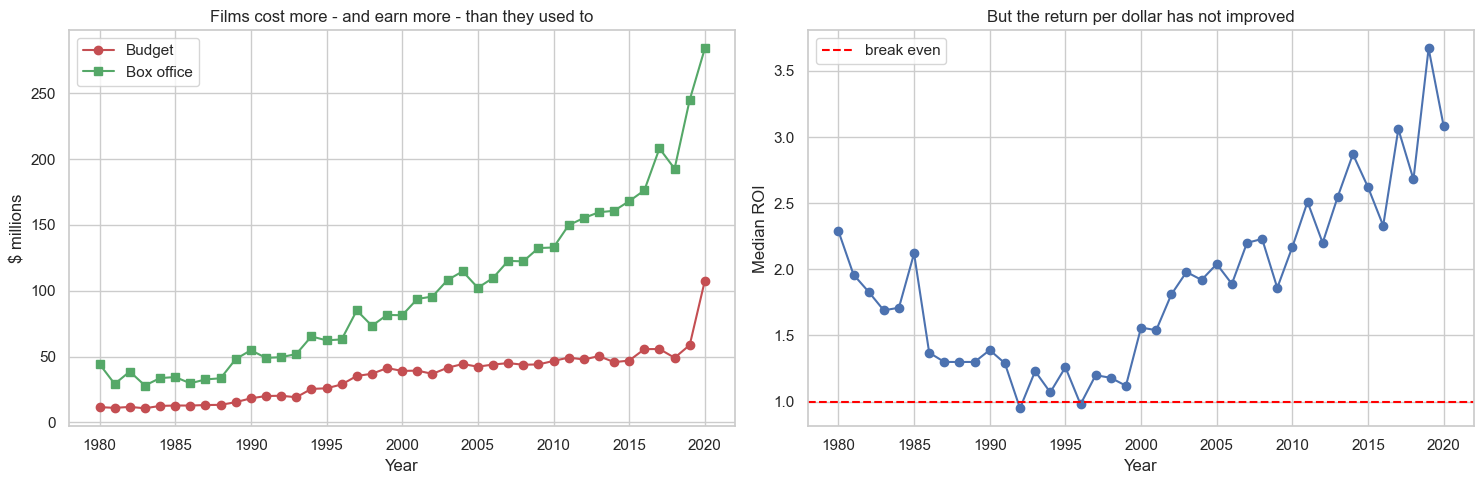

In [11]:
collection = CSVLoader(PROJECT_ROOT / "data" / "movies.csv").to_collection()
trend_table = TrendAnalyzer(collection).report()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(trend_table.index, trend_table["avg_budget"] / 1e6,
             marker="o", label="Budget", color="#C44E52")
axes[0].plot(trend_table.index, trend_table["avg_gross"] / 1e6,
             marker="s", label="Box office", color="#55A868")
axes[0].set_title("Films cost more - and earn more - than they used to")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("$ millions")
axes[0].legend()

axes[1].plot(trend_table.index, trend_table["median_roi"],
             marker="o", color="#4C72B0")
axes[1].axhline(1.0, color="red", linestyle="--", label="break even")
axes[1].set_title("But the return per dollar has not improved")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Median ROI")
axes[1].legend()

plt.tight_layout()
plt.show()

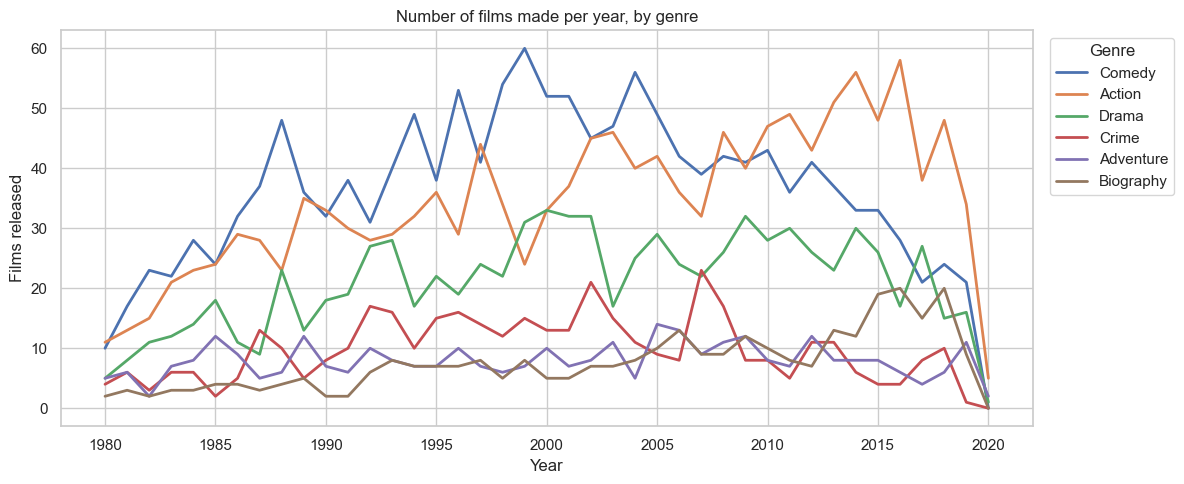

In [12]:
# Which genres has the industry shifted towards?
by_year_genre = (df.groupby(["year", "genre_group"]).size()
                   .unstack(fill_value=0))
top_genres = df["genre_group"].value_counts().head(6).index

by_year_genre[top_genres].plot(figsize=(12, 5), linewidth=2)
plt.title("Number of films made per year, by genre")
plt.ylabel("Films released")
plt.xlabel("Year")
plt.legend(title="Genre", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Takeaway:** budgets have grown enormously since 1980, and box office has grown with
them - but the *ratio* between the two has stayed roughly flat. Spending more has not made
the industry more efficient, only bigger.

## 7. Does the age rating affect the money?

`FinancialAnalyzer` uses **multiple inheritance** - it is a `BaseAnalyzer` *and* an
`ExportMixin`, which means it can also save its results to a file.

In [13]:
financial = FinancialAnalyzer(collection)
rating_table = financial.report()
rating_table

[timed] run took 1.8 ms

=== Financial Analysis ===
 * 32.1% of all films failed to earn back their budget
 * Most profitable film: Avatar (2009) made $2.61B
 * Highest grossing age rating: TV-MA ($350.0M average)


,movies,avg_budget,avg_gross,avg_profit,median_roi
rating,,,,,
TV-MA,2,"27,000,000.00","350,041,644.50","323,041,644.50",7.30
G,111,"53,302,432.43","189,245,253.81","135,942,821.38",2.71
PG-13,1729,"51,002,477.02","154,159,800.14","103,157,323.12",2.08
PG,907,"44,092,214.74","137,743,019.97","93,650,805.23",2.05
R,2595,"23,298,037.61","55,953,618.66","32,655,581.05",1.56
Approved,1,"6,500,000.00","36,565,280.00","30,065,280.00",5.63
Not Rated,44,"8,402,300.64","21,464,278.20","13,061,977.57",0.69
X,1,"17,000,000.00","17,186,348.00","186,348.00",1.01
NC-17,12,"10,062,500.00","15,942,256.75","5,879,756.75",1.83


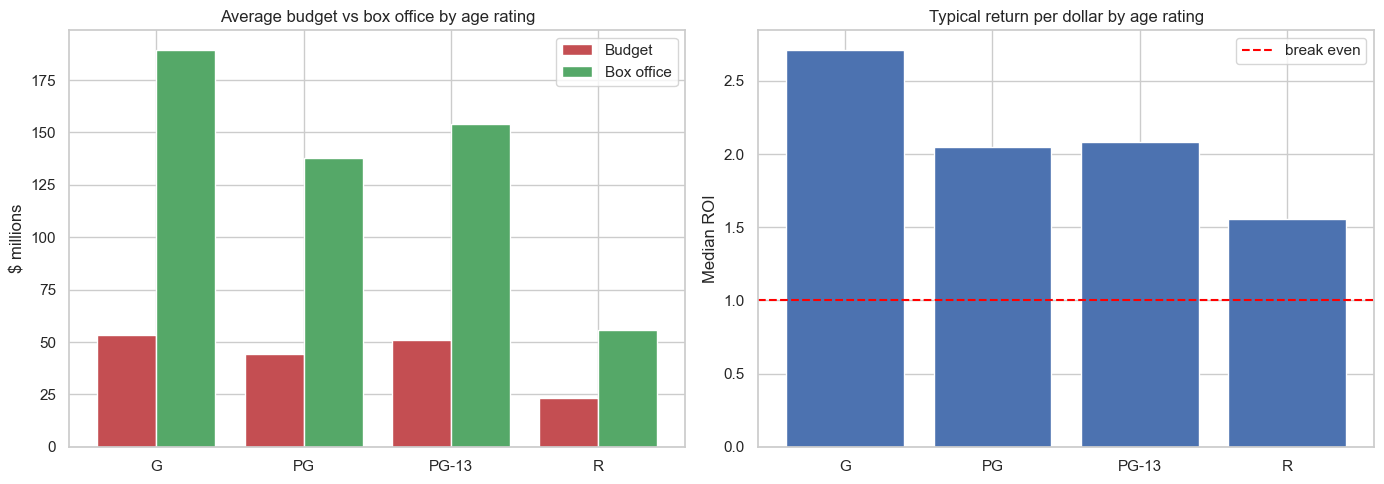

In [14]:
main_ratings = ["G", "PG", "PG-13", "R"]
subset = rating_table.loc[[r for r in main_ratings if r in rating_table.index]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(subset))
axes[0].bar(x - 0.2, subset["avg_budget"] / 1e6, 0.4, label="Budget", color="#C44E52")
axes[0].bar(x + 0.2, subset["avg_gross"] / 1e6, 0.4, label="Box office", color="#55A868")
axes[0].set_xticks(x)
axes[0].set_xticklabels(subset.index)
axes[0].set_title("Average budget vs box office by age rating")
axes[0].set_ylabel("$ millions")
axes[0].legend()

axes[1].bar(subset.index, subset["median_roi"], color="#4C72B0")
axes[1].axhline(1.0, color="red", linestyle="--", label="break even")
axes[1].set_title("Typical return per dollar by age rating")
axes[1].set_ylabel("Median ROI")
axes[1].legend()

plt.tight_layout()
plt.show()

**Takeaway:** **G** and **PG** films earn far more on average than **R**-rated ones, because
the whole family can buy a ticket. An R rating shuts out a large part of the audience.

## 8. Which numbers move together?

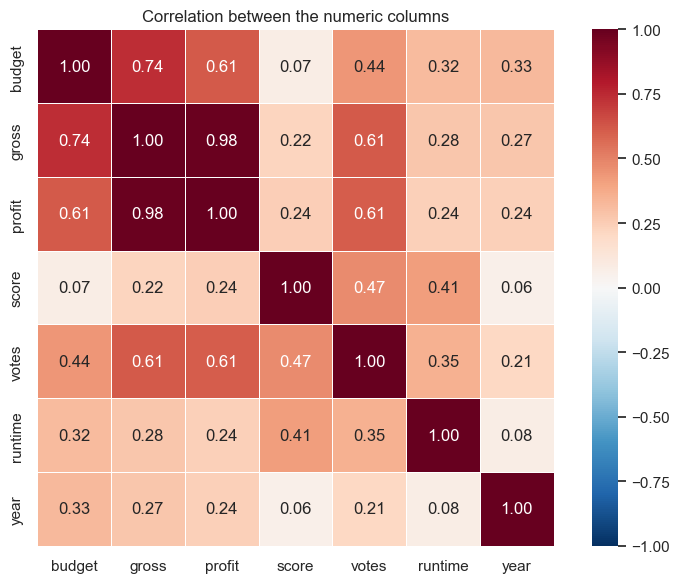

How strongly does each column relate to box office?
profit    0.98
budget    0.74
votes     0.61
runtime   0.28
year      0.27
score     0.22
Name: gross, dtype: float64


In [15]:
numeric_columns = ["budget", "gross", "profit", "score", "votes", "runtime", "year"]
correlations = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation between the numeric columns")
plt.tight_layout()
plt.show()

print("How strongly does each column relate to box office?")
print(correlations["gross"].drop("gross").sort_values(ascending=False))

**Takeaway:** **budget has the strongest link to box office (0.74)**. `votes` is also high,
but that is a trap - a film only collects votes *after* it comes out, so we cannot use it
to predict a film that has not been made yet. Note how weak `score` is (0.22): critics and
cash have surprisingly little to do with each other.

## 9. The central relationship: budget vs box office

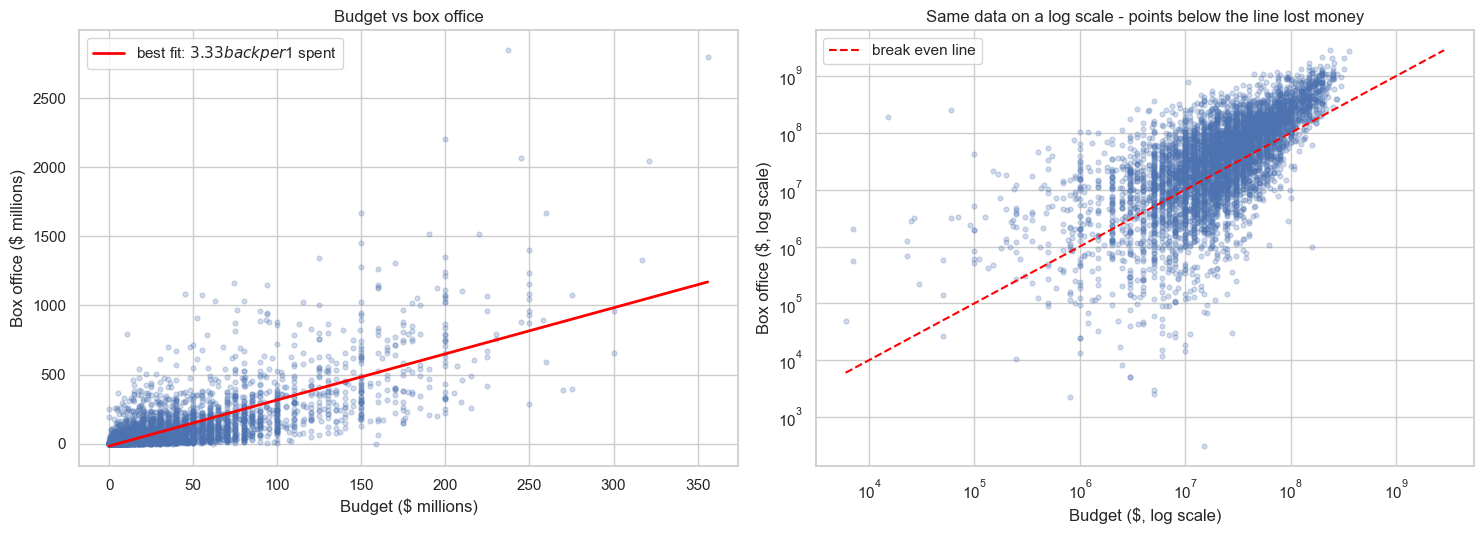

Correlation between budget and box office: 0.740
On average, every $1 of budget returns about $3.33 at the box office.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].scatter(df["budget"] / 1e6, df["gross"] / 1e6,
                alpha=0.25, s=12, color="#4C72B0")
slope, intercept = np.polyfit(df["budget"], df["gross"], 1)
line_x = np.linspace(df["budget"].min(), df["budget"].max(), 100)
axes[0].plot(line_x / 1e6, (slope * line_x + intercept) / 1e6,
             color="red", linewidth=2, label=f"best fit: ${slope:.2f} back per $1 spent")
axes[0].set_xlabel("Budget ($ millions)")
axes[0].set_ylabel("Box office ($ millions)")
axes[0].set_title("Budget vs box office")
axes[0].legend()

axes[1].scatter(df["budget"], df["gross"], alpha=0.25, s=12, color="#4C72B0")
limits = [df["budget"].min(), df["gross"].max()]
axes[1].plot(limits, limits, color="red", linestyle="--", label="break even line")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Budget ($, log scale)")
axes[1].set_ylabel("Box office ($, log scale)")
axes[1].set_title("Same data on a log scale - points below the line lost money")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Correlation between budget and box office: {df['budget'].corr(df['gross']):.3f}")
print(f"On average, every $1 of budget returns about ${slope:.2f} at the box office.")

**Takeaway:** the relationship is clearly real - the cloud of points slopes upwards, and
every extra dollar of budget is worth roughly **$3.30** at the box office on average. But
look how wide the cloud is: at any given budget, some films earn ten times more than
others. Budget tells us a lot, but nowhere near everything.

## 10. Does spending more money make a *better* film?

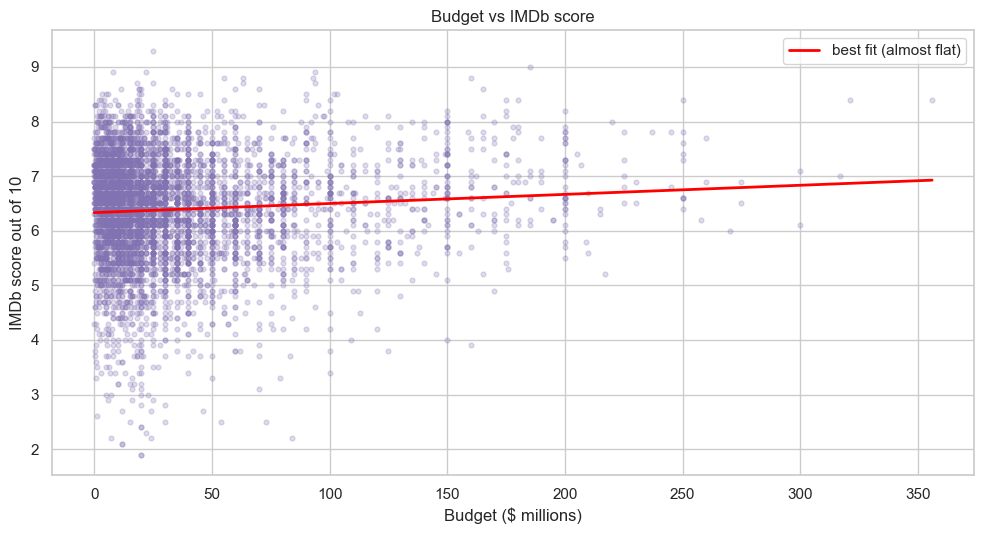

Correlation between budget and IMDb score: 0.072


In [17]:
plt.figure(figsize=(10, 5.5))
plt.scatter(df["budget"] / 1e6, df["score"], alpha=0.25, s=12, color="#8172B2")

slope_s, intercept_s = np.polyfit(df["budget"], df["score"], 1)
line_x = np.linspace(df["budget"].min(), df["budget"].max(), 100)
plt.plot(line_x / 1e6, slope_s * line_x + intercept_s,
         color="red", linewidth=2, label="best fit (almost flat)")

plt.xlabel("Budget ($ millions)")
plt.ylabel("IMDb score out of 10")
plt.title("Budget vs IMDb score")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlation between budget and IMDb score: {df['budget'].corr(df['score']):.3f}")

**Takeaway:** the best-fit line is nearly flat, and the correlation is **0.07** - which is
statistically indistinguishable from nothing. **Money buys an audience, not a good film.**
This is the most quotable finding in the whole notebook.

## 11. When should you release, and how risky is it?

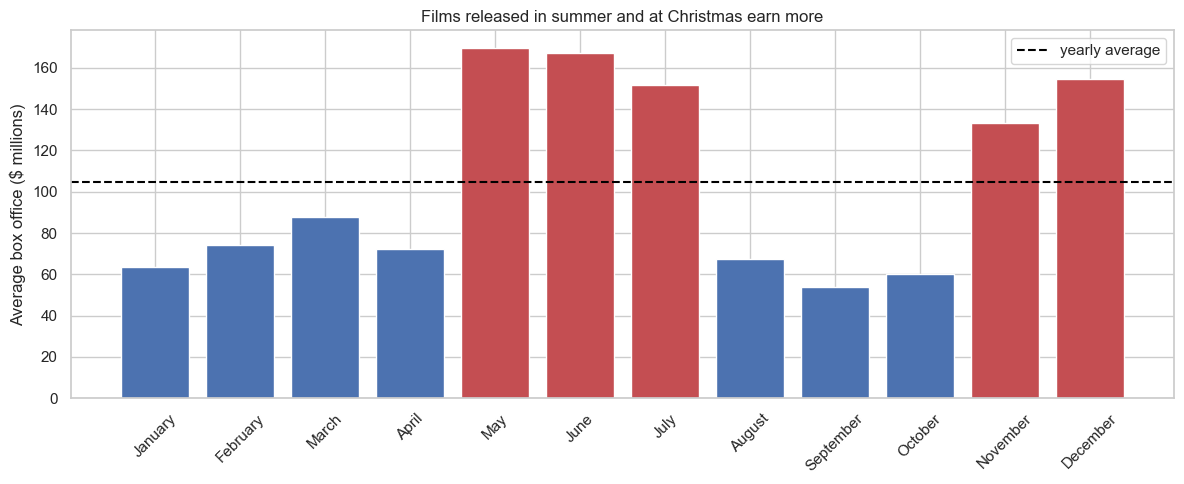

Best month:  May ($169.7M average)
Worst month: September ($53.8M average)


In [18]:
month_order = CSVLoader.MONTHS
by_month = (df.groupby("month")
              .agg(films=("name", "count"), avg_gross=("gross", "mean"))
              .reindex(month_order))

plt.figure(figsize=(12, 5))
colors = ["#C44E52" if v > by_month["avg_gross"].mean() else "#4C72B0"
          for v in by_month["avg_gross"]]
plt.bar(by_month.index, by_month["avg_gross"] / 1e6, color=colors)
plt.axhline(by_month["avg_gross"].mean() / 1e6, color="black",
            linestyle="--", label="yearly average")
plt.ylabel("Average box office ($ millions)")
plt.title("Films released in summer and at Christmas earn more")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

best_month = by_month["avg_gross"].idxmax()
worst_month = by_month["avg_gross"].idxmin()
print(f"Best month:  {best_month} ({money(by_month.loc[best_month, 'avg_gross'])} average)")
print(f"Worst month: {worst_month} ({money(by_month.loc[worst_month, 'avg_gross'])} average)")

32.1% of all films failed to earn back their budget.



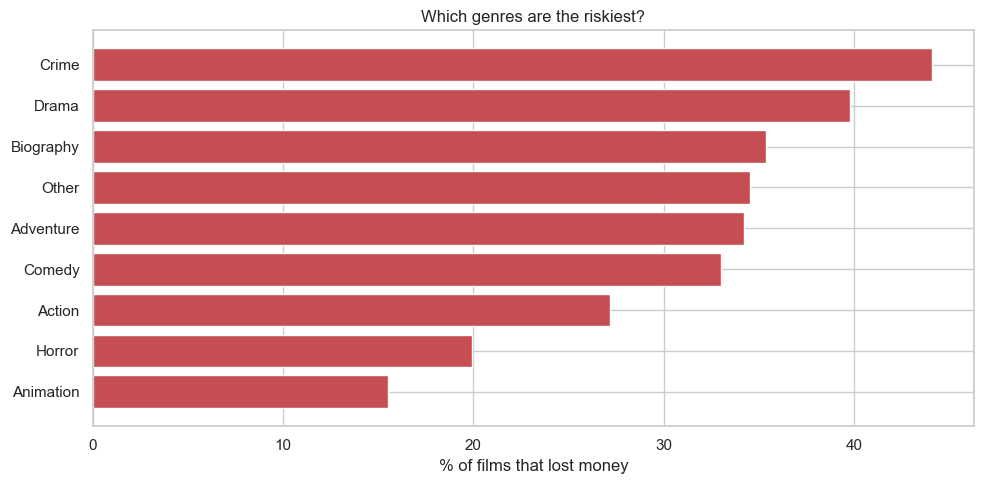

In [19]:
# How risky is film making overall?
df_risk = df.assign(flopped=df["gross"] < df["budget"])
overall_flop_rate = df_risk["flopped"].mean() * 100
print(f"{overall_flop_rate:.1f}% of all films failed to earn back their budget.\n")

flop_by_genre = (df_risk.groupby("genre_group")["flopped"].mean() * 100).sort_values()
plt.figure(figsize=(10, 5))
plt.barh(flop_by_genre.index, flop_by_genre.values, color="#C44E52")
plt.xlabel("% of films that lost money")
plt.title("Which genres are the riskiest?")
plt.tight_layout()
plt.show()

**Takeaway:** release timing matters - summer and December releases earn noticeably more
than the January dead zone. And film making is genuinely risky: roughly **a third of all
films never earn back their budget**.

## 12. Predicting box office with linear regression

Now the model that powers the app in Part 2.

### Why we leave out `score` and `votes`

A film only has an IMDb score and a vote count **after** it has been released. If we fed
those into a model that claims to predict an unmade film, we would be using information
that will not exist at the time we need the prediction. That mistake has a name:
**data leakage**. So the model only sees things known *before* release:

`budget`, `runtime`, `year`, `genre`, `age rating`, and `release month`.

In [20]:
predictor = SuccessPredictor(collection)
r2 = predictor.train()

print(f"Trained on {len(predictor.df):,} films.")
print(f"R-squared on unseen films: {r2:.3f}")
print(f"  -> the model explains about {r2 * 100:.0f}% of the variation in box office.")
print(f"Average error: {money(predictor.mae)}")

Trained on 5,418 films.
R-squared on unseen films: 0.588
  -> the model explains about 59% of the variation in box office.
Average error: $66.9M


### An honest comparison

It is tempting to stop there. But how much are genre, rating and release month actually
contributing? Let us train a second model that sees **budget and nothing else**.

In [21]:
simple_r2 = predictor.budget_only_r2()

print(f"All pre-release features: R-squared = {r2:.3f}")
print(f"Budget alone:             R-squared = {simple_r2:.3f}")
print(f"Everything else adds:                 {r2 - simple_r2:.3f}")

All pre-release features: R-squared = 0.588
Budget alone:             R-squared = 0.579
Everything else adds:                 0.010


**This is the most important result in the notebook.** Genre, age rating and release month
together add less than **0.01** to the model's accuracy. Almost all of the predictive power
comes from the budget alone.

That is a genuine finding, not a failure. It says something real about the film industry:
**how much you spend is by far the best available predictor of how much you will earn**,
and the other things we can know in advance barely matter.

In [22]:
# Which features push the prediction up or down the most?
print("Biggest influences on the prediction:\n")
for feature, weight in predictor.top_coefficients(10).items():
    direction = "increases" if weight > 0 else "decreases"
    if feature == "budget":
        print(f"  {feature:28} every extra $1 of budget {direction} "
              f"predicted gross by ${weight:.2f}")
    else:
        print(f"  {feature:28} {direction} predicted gross by {money(abs(weight))}")

Biggest influences on the prediction:

  rating_TV-MA                 increases predicted gross by $236.5M
  rating_X                     decreases predicted gross by $77.7M
  genre_group_Animation        increases predicted gross by $71.4M
  genre_group_Horror           increases predicted gross by $47.0M
  rating_Not Rated             decreases predicted gross by $36.3M
  genre_group_Other            increases predicted gross by $31.5M
  rating_R                     decreases predicted gross by $31.1M
  month_June                   increases predicted gross by $29.7M
  month_May                    increases predicted gross by $27.8M
  month_July                   increases predicted gross by $27.5M


In [23]:
# Try the model out on some imaginary films.
ideas = [
    (200_000_000, "Action",    "PG-13", 140, 2020, "July"),
    (5_000_000,   "Horror",    "R",      95, 2020, "October"),
    (150_000_000, "Animation", "PG",    100, 2020, "December"),
    (20_000_000,  "Drama",     "R",     130, 2020, "January"),
]

print(f"{'Film idea':<38}{'Predicted':>14}{'Profit':>14}   Verdict")
print("-" * 82)
for budget, genre, rating, runtime, year, month in ideas:
    result = predictor.predict(budget, genre, rating, runtime, year, month)
    label = f"{money(budget)} {genre}, {rating}, {month}"
    print(f"{label:<38}{money(result['gross']):>14}"
          f"{money(result['profit']):>14}   {result['verdict']}")

Film idea                                  Predicted        Profit   Verdict
----------------------------------------------------------------------------------
$200.0M Action, PG-13, July                  $647.2M       $447.2M   Hit
$5.0M Horror, R, October                      $26.5M        $21.5M   Hit
$150.0M Animation, PG, December              $462.7M       $312.7M   Hit
$20.0M Drama, R, January                     $102.3M        $82.3M   Hit


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


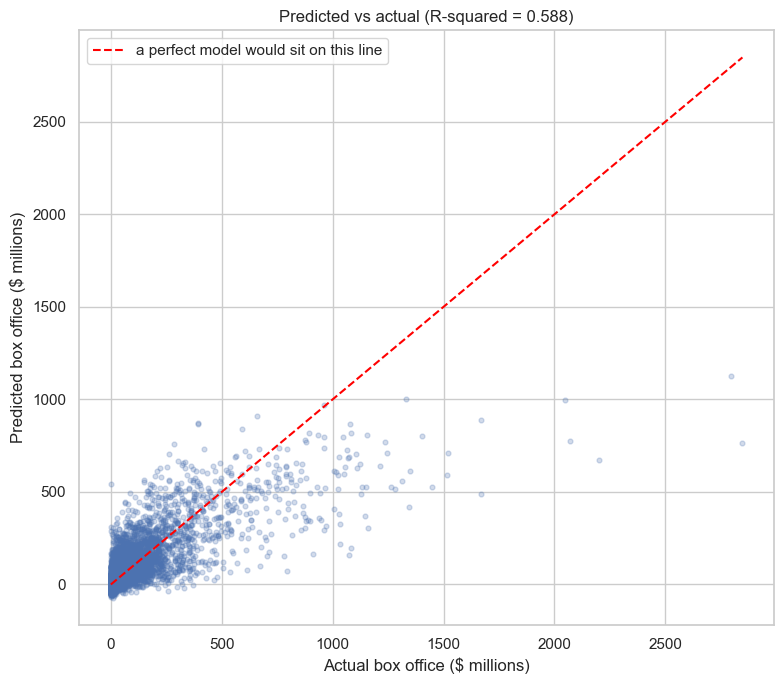

In [24]:
# How close are the predictions to reality?
features = predictor._build_features(predictor.df)
predicted = predictor.model.predict(features)
actual = predictor.df["gross"]

plt.figure(figsize=(8, 7))
plt.scatter(actual / 1e6, predicted / 1e6, alpha=0.25, s=12, color="#4C72B0")
top = max(actual.max(), predicted.max()) / 1e6
plt.plot([0, top], [0, top], color="red", linestyle="--",
         label="a perfect model would sit on this line")
plt.xlabel("Actual box office ($ millions)")
plt.ylabel("Predicted box office ($ millions)")
plt.title(f"Predicted vs actual (R-squared = {r2:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

**Takeaway:** the model explains about **59%** of the difference between films, using only
information available before a single frame is shot. The remaining 41% is everything a
spreadsheet cannot capture: the script, the cast, the marketing, the reviews, and luck.

That is a useful and honest result - and it is exactly what the Predict tab of the app
shows the user, R-squared included, so nobody mistakes the estimate for a promise.

---

## Summary of findings

| # | Question | Answer |
|---|----------|--------|
| 1 | Which genre gives the best return? | **Horror** - typically about 3x its budget |
| 2 | Which genre is safest? | **Animation** - the lowest share of money-losing films |
| 3 | Does a bigger budget mean a better film? | **No.** Correlation with IMDb score is 0.07 |
| 4 | Does a bigger budget mean more money? | **Yes.** Correlation 0.74; about $3.30 back per $1 |
| 5 | Does the age rating matter? | **Yes.** G and PG films out-earn R-rated ones |
| 6 | When is the best time to release? | **Summer and December**; January is the worst |
| 7 | How risky is film making? | About **a third of films** never make their money back |
| 8 | Can we predict box office in advance? | **Partly** - R-squared 0.59, almost all of it from budget |

**Next:** Part 2 wraps these same classes in a Tkinter application, so the analysis can be
explored by clicking instead of by editing code. Run it with `python main.py`.